In [4]:
import numpy as np
import dpluspy
import pickle
import matplotlib.pyplot as plt

import matplotlib, matplotlib.pylab as plt
plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [ ]:
# Run bootstraps and subset

def run_bootstrap(pattern, weighted):
    in_fnames = [f"../recombination_maps/data/sums/sums_{pattern}_chr{i}.pkl" 
        for i in range(1, 23)]
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)
    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]
    replicates = dpluspy.bootstrapping.get_bootstrap_reps(sums, weighted=weighted)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    if weighted:
        means = dpluspy.bootstrapping.weighted_means_across_regions(sums)
    else:
        means = dpluspy.bootstrapping.means_across_regions(sums)
    
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
    }

    return data


wdata = run_bootstrap("Bherer", True)
data = run_bootstrap("Bherer", False)

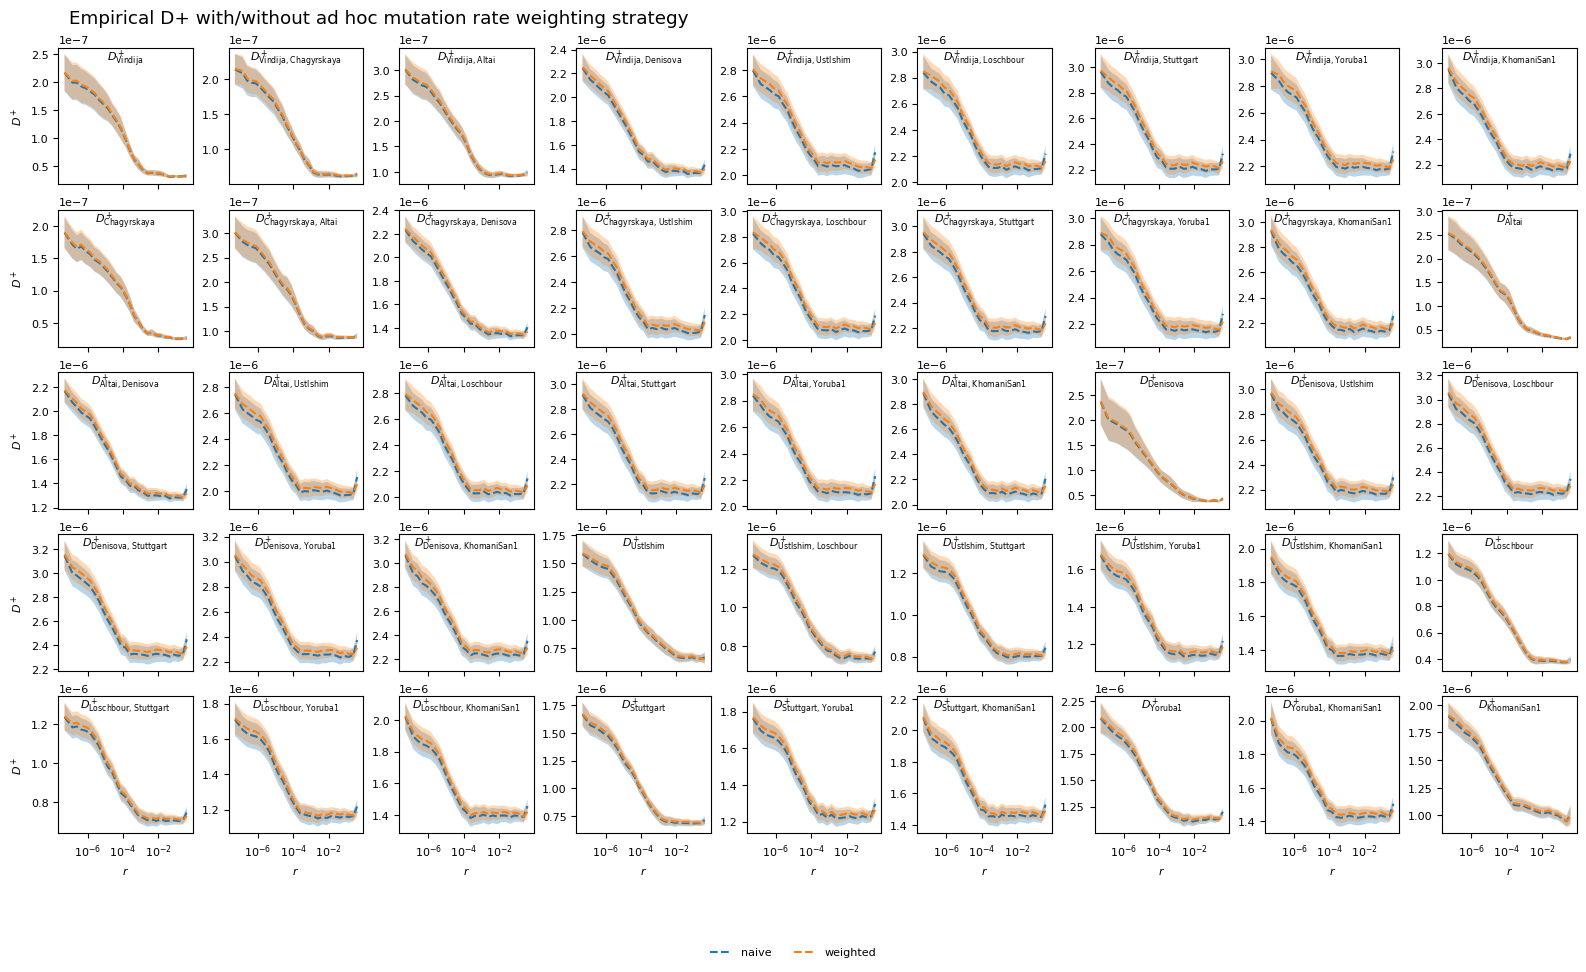

In [6]:
plot_pops = [
    "Vindija",
    "Chagyrskaya",
    "Altai",
    "Denisova",
    "UstIshim",
    "Loschbour",
    "Stuttgart",
    "Yoruba1",
    "KhomaniSan1"
]

wdata = dpluspy.bootstrapping.subset_stats(wdata, to_pops=plot_pops, return_dict=True)
data = dpluspy.bootstrapping.subset_stats(data, to_pops=plot_pops, return_dict=True)

dpluspy.plotting.plot_D_plus_curves(
    means=[data["means"], wdata["means"]], 
    varcovs=[data["varcovs"], wdata["varcovs"]], 
    bins=data["bins"],
    pop_ids=plot_pops, 
    labels=["naive", "weighted"], 
    out=f"figures/fig_weighting.pdf",
    title=f"Empirical D+ with/without ad hoc mutation rate weighting strategy",
    show=False,
    cols=9,
    ax_size=1.75,
    colors=["tab:blue", "tab:orange"]
)